# 1. Importing libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from datetime import datetime as dt
import seaborn as sns

# 2. Loading data

In [2]:
df = pd.read_csv('NY_data.csv', low_memory=False, encoding='latin1', index_col = 0)

In [3]:
# dropping unnecesary columns
df.drop(columns = {'Unnamed: 0', '_merge'}, inplace = True)

In [4]:
# changin date to time format
df['date'] = pd.to_datetime(df['date'])

In [5]:
# saving previous corrections so that next time I don't need to do it again
df.to_csv('NY_data_1.csv')

In [6]:
df.dtypes

ride_id                           object
rideable_type                     object
started_at                        object
ended_at                          object
start_station_name                object
start_station_id                  object
end_station_name                  object
end_station_id                    object
start_lat                        float64
start_lng                        float64
end_lat                          float64
end_lng                          float64
member_casual                     object
 255}                             object
 {920                             object
 789}}\t#/;R_klmnoÂ            object
date                      datetime64[ns]
avgTemp                          float64
dtype: object

# 3. Setting theme

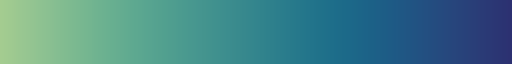

In [24]:
sns.set_style("white")
sns.color_palette("crest", as_cmap=True)

# 4. Bar chart

In [10]:
df['value'] = 1

In [11]:
df_t = df.groupby('start_station_name')['value'].count().reset_index()

In [12]:
top20 = df_t.nlargest(20, 'value')

In [13]:
top20

,start_station_name,value
1587,W 21 St & 6 Ave,129018
1718,West St & Chambers St,123291
495,Broadway & W 58 St,114293
286,6 Ave & W 33 St,106445
8,1 Ave & E 68 St,104856
461,Broadway & E 14 St,98866
485,Broadway & W 25 St,98425
1511,University Pl & E 14 St,97126
463,Broadway & E 21 St,95691
1603,W 31 St & 7 Ave,94208


/var/folders/0v/41kfhzq16_1d4jx6rzjml39m0000gn/T/ipykernel_20238/2577369999.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top20, x = 'value', y = 'start_station_name', palette=("crest"))


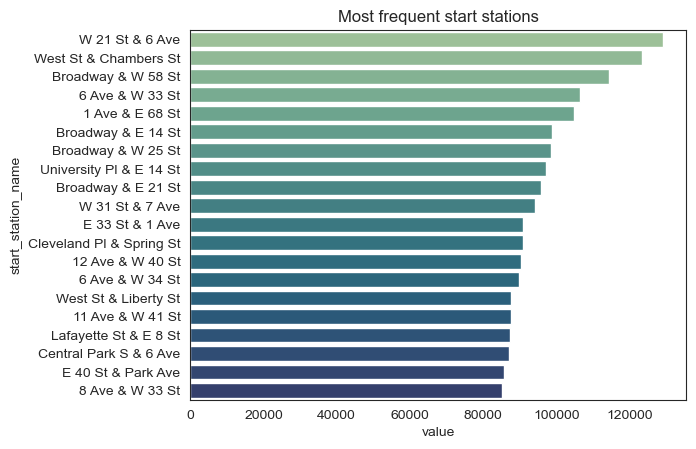

In [32]:
sns.barplot(data = top20, x = 'value', y = 'start_station_name', palette=("crest"))
plt.title("Most frequent start stations")
plt.show()

# 5. Line chart

In [34]:
df_group = pd.DataFrame(df.groupby(['date'])['ride_id'].count()).reset_index()

In [35]:
df_group_1 = df_group.drop(labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36], axis=0)

In [36]:
df_group_1.rename(columns = {'ride_id':'bike_rides_daily'}, inplace = True)
df = df.merge(df_group_1, on = "date", how = 'outer', indicator = True)
print(df['_merge'].value_counts(dropna = False))
print("Shape of January 1st is", df[df['date'] == '2022-01-01'].shape) # Check 
print("Shape of January 2nd is", df[df['date'] == '2022-01-02'].shape) # Second check 

df_temp = df.set_index('date')

print(df_temp.columns)

_merge
both          29838166
left_only          655
right_only           0
Name: count, dtype: int64
Shape of January 1st is (20428, 21)
Shape of January 2nd is (43009, 21)
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', ' 255}', ' {920', ' 789}}\#/;R_klmnoÂ', 'avgTemp',
       'value', 'bike_rides_daily', '_merge'],
      dtype='object')


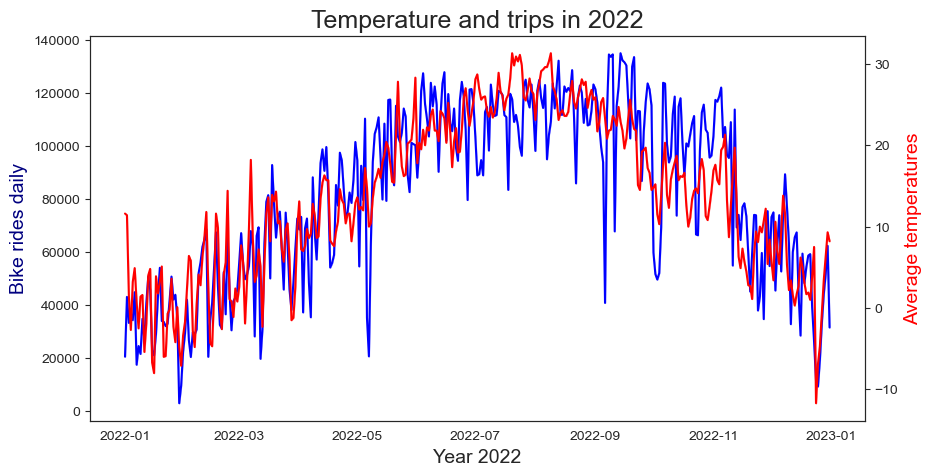

In [38]:
fig,ax = plt.subplots(figsize=(10, 5))

sns.lineplot(data = df_temp['bike_rides_daily'], color = "b")
ax.set_xlabel("Year 2022", fontsize = 14)
ax.set_ylabel("Bike rides daily", color = "navy", fontsize = 14)

ax2 = ax.twinx()

sns.lineplot(data = df_temp["avgTemp"], color = "r", ax=ax2)
ax2.set_ylabel("Average temperatures", color = "red", fontsize=14)
plt.title('Temperature and trips in 2022', fontsize = 18)
plt.show()

# 6. Bar chart of a categorical variable

/var/folders/0v/41kfhzq16_1d4jx6rzjml39m0000gn/T/ipykernel_20238/1850748141.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'member_casual', palette=("crest"))


<Axes: xlabel='member_casual', ylabel='count'>

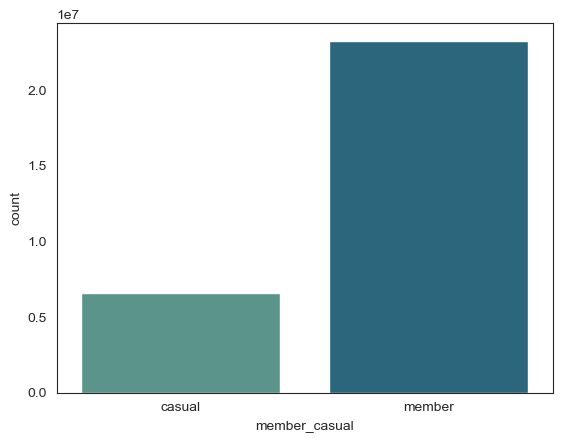

In [42]:
sns.countplot(data = df, x = 'member_casual', palette=("crest"))

This chart shows that there are roughly three times more member users compared to casual users. This shows that a lot of customers value this brand and register as loyal customers which is great for customer retention. It would be interesting to see how these numbers change over time.

# 7. FaceGrid plot

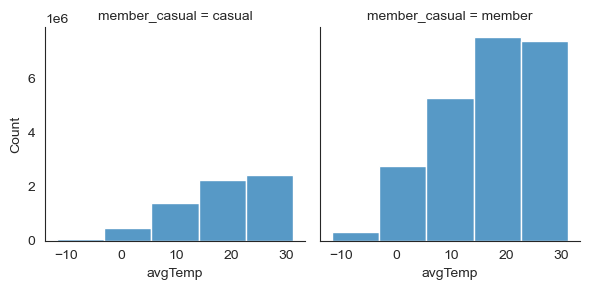

In [48]:
grid = sns.FacetGrid(df, col = "member_casual")
grid.map(sns.histplot, "avgTemp", bins = 5)

FaceGrid creates a grid of subplots based on categorical variables. For the purposes of this project, it would be useful to look into the difference in bike rides depending on the customer status and temperature at the time. From the FaceGrid plot we can see that at the time of extemely low temperatures, only member users use the bike and the new customers do not use it at all. Might be good to suggest discounts for new members on days with temperatures below 10C.